# Contents
## 1. Problem Statement

## 2. Data Exploration

 * Libraries 
 * Import Dataset 
 * Dataset Overview and Variable Description
 * Data Cleaning and Data Preprocessing

## 3. Data Analysis

### Univariate Analysis
 * Id 
 * Vendor Id 
 * Passenger 
 * Trip Duration
 * Distance
 * Speed
 * Total trips per hour
 * Total trips per Weekday
 * Total trips per Month

### Bivariate Analysis
 * Trip Duration per Hour
 * Trip Duration per Week
 * Trip Duration per Month
 * Trip Duration per Vendor
 * Distance per hour
 * Distance per WeekDay
 * Distance per Month
 * Distance per Vendor
 * Distance v/s Trip Duration
 * Average Speed per Hour
 * Average Speed per WeekDay
 * Passenger count per Vendor
 * Pick Up v/s Dropoff Points

## 4. Feature Engineering
 * Feature Selection
 * Feature Extraction
 * Correlation Analysis
   * HeatMap

# Problem Statement

# Exploratory Data Analysis on NYC Taxi Trip Duration data

**Data Exploration**

**Libraries**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from geopy.distance import geodesic
import time
from IPython.display import clear_output

**Import Data**  

Import the data from the csv file

In [2]:
df = pd.read_csv("nyc_taxi_trip_duration.csv")

**Dataset Overview and Variable Descriptions**

In [3]:
df.dtypes

id                     object
vendor_id               int64
pickup_datetime        object
dropoff_datetime       object
passenger_count         int64
pickup_longitude      float64
pickup_latitude       float64
dropoff_longitude     float64
dropoff_latitude      float64
store_and_fwd_flag     object
trip_duration           int64
dtype: object

In [4]:
df.shape

(729322, 11)

In [5]:
df.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration'],
      dtype='object')

In [6]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id1080784,2,2016-02-29 16:40:21,2016-02-29 16:47:01,1,-73.953918,40.778873,-73.963875,40.771164,N,400
1,id0889885,1,2016-03-11 23:35:37,2016-03-11 23:53:57,2,-73.988312,40.731743,-73.994751,40.694931,N,1100
2,id0857912,2,2016-02-21 17:59:33,2016-02-21 18:26:48,2,-73.997314,40.721458,-73.948029,40.774918,N,1635
3,id3744273,2,2016-01-05 09:44:31,2016-01-05 10:03:32,6,-73.961670,40.759720,-73.956779,40.780628,N,1141
4,id0232939,1,2016-02-17 06:42:23,2016-02-17 06:56:31,1,-74.017120,40.708469,-73.988182,40.740631,N,848


In [7]:
df.tail()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
729317,id3905982,2,2016-05-21 13:29:38,2016-05-21 13:34:34,2,-73.965919,40.789780,-73.952637,40.789181,N,296
729318,id0102861,1,2016-02-22 00:43:11,2016-02-22 00:48:26,1,-73.996666,40.737434,-74.001320,40.731911,N,315
729319,id0439699,1,2016-04-15 18:56:48,2016-04-15 19:08:01,1,-73.997849,40.761696,-74.001488,40.741207,N,673
729320,id2078912,1,2016-06-19 09:50:47,2016-06-19 09:58:14,1,-74.006706,40.708244,-74.013550,40.713814,N,447
729321,id1053441,2,2016-01-01 17:24:16,2016-01-01 17:44:40,4,-74.003342,40.743839,-73.945847,40.712841,N,1224


**Data Cleaning and Data Preprocessing**

1.Missing Value Analysis

In [8]:
df.isna().sum()

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

There are no Null Values

2.Convert timestamp to datetime format to fetch the other details as listed below

In [9]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])

In [10]:
#Calculate and assign new columns to the dataframe such as weekday,
#month and pickup_hour which will help us to gain more insights from the data.

df['weekday'] = df['pickup_datetime'].dt.day_name()    
df['month'] = df['pickup_datetime'].dt.month
df['weekday_num'] = df['pickup_datetime'].dt.weekday
df['pickup_hour'] = df['pickup_datetime'].dt.hour


3.Calculate distance between pickup and dropoff coordinates using Haversine formula.

In [11]:
from math import radians, sin, cos, sqrt, asin

def haversine(lat1, lon1, lat2, lon2):
    # Convert degrees to radians
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    r = 3956  # Earth radius in miles
    return c * r

# Vectorized version
vectorized_haversine = np.vectorize(haversine)
df['distance'] = vectorized_haversine(
    df['pickup_latitude'], 
    df['pickup_longitude'],
    df['dropoff_latitude'], 
    df['dropoff_longitude']
)

4.Calculate Speed in miles/hr for further insights

In [12]:
df['speed'] = (df.distance/(df.trip_duration/3600))

**Column Details**

* id - a unique identifier for each trip
* vendor_id - a code indicating the provider associated with the trip record
* pickup_datetime - date and time when the meter was engaged
* dropoff_datetime - date and time when the meter was disengaged
* passenger_count - the number of passengers in the vehicle (driver entered value)
* pickup_longitude - the longitude where the meter was engaged
* pickup_latitude - the latitude where the meter was engaged
* dropoff_longitude - the longitude where the meter was disengaged
* dropoff_latitude - the latitude where the meter was disengaged
* store_and_fwd_flag - This flag indicates whether the trip record was held in vehicle memory before sending to the vendor because the vehicle did not have a connection to the server - Y=store and forward; N=not a store and forward trip.
* trip_duration - duration of the trip in seconds
* distance - geographic distance between two co-ordinates
* speed - average spped of the trip (in miles/hr)

**Data Analysis**

This section represent the Univariate and Bivariate analysis of the data

**Univariate Analysis**

Univariate analysis is the analysis of one variable. It's major purpose is to describe patterns in the data consisting of single variable.

**1. Id**

There are 729322 Unique id's which represent each row in the data

**2. Vender Id**

A code indicating the provider associated with the trip record

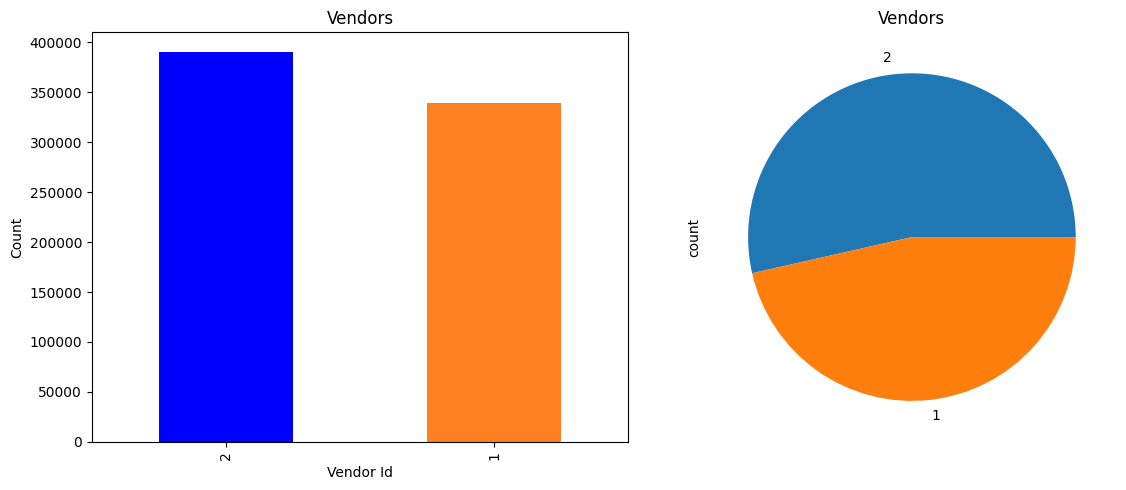

In [13]:
fig, axes = plt.subplots(nrows=1, ncols=2,figsize=(12,5))
ax = df['vendor_id'].value_counts().plot(kind='bar',title="Vendors",ax=axes[0],color = ('blue',(1, 0.5, 0.13)))
df['vendor_id'].value_counts().plot(kind='pie',title="Vendors",ax=axes[1])
ax.set_ylabel("Count")
ax.set_xlabel("Vendor Id")
fig.tight_layout()

Here we got to know that there are only 2 venders(1 and 2)
* Both the venders share almost equal amount of trips, the difference is quite low between two venders
* But Vendor 2 is evidently more famous among the population as per the above graphs.

**3. Passengers**

New York City Taxi Passenger Limit says:

* A maximum of 4 passengers can ride in traditional cabs.
* A child under 7 is allowed to sit on a passenger\'s lap in the rear seat in addition to the passenger limit.

So, in total we can assume that maximum 5 passenger can board the new york taxi i.e. 4 adult + 1 minor



In [14]:
pd.options.display.float_format = '{:.2f}'.format #To suppress scientific notation.
df.passenger_count.value_counts()

passenger_count
1    517415
2    105097
5     38926
3     29692
6     24107
4     14050
0        33
7         1
9         1
Name: count, dtype: int64

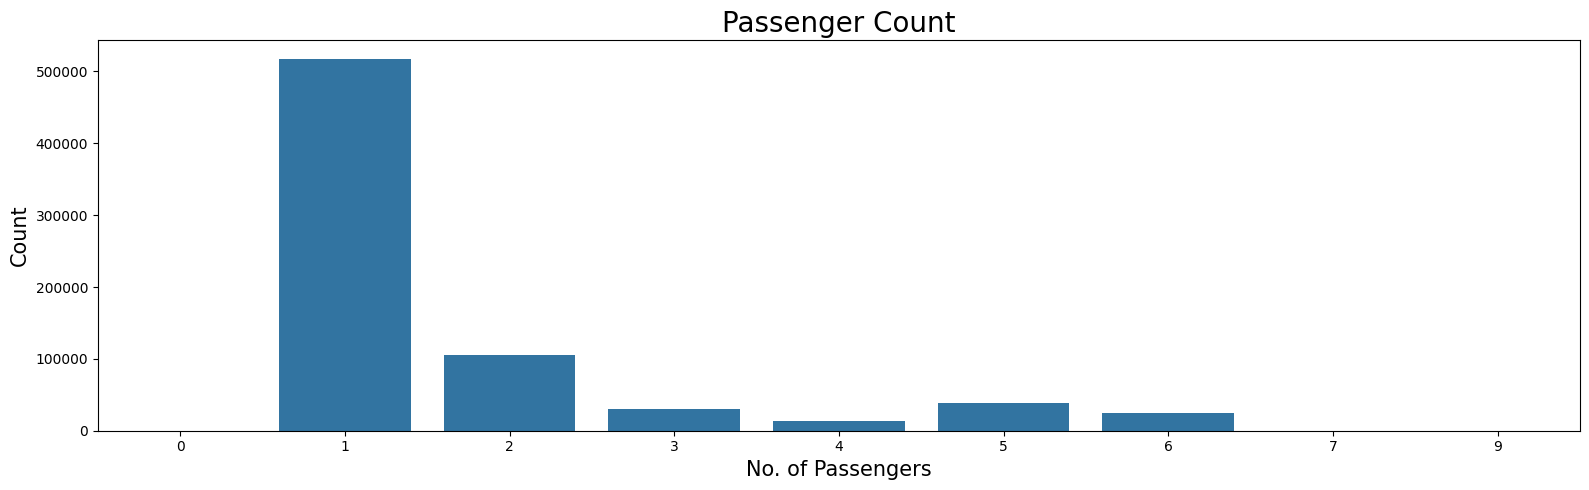

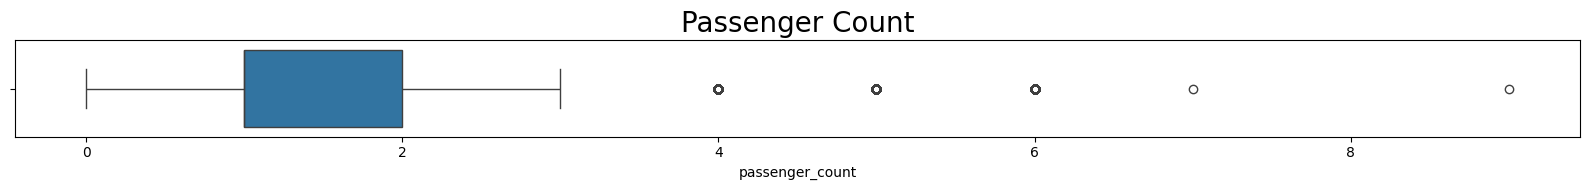

In [15]:

plt.figure(figsize=(16,5))
sns.countplot(x='passenger_count', data=df)
plt.ylabel("Count", fontsize=15)
plt.xlabel("No. of Passengers", fontsize=15)
plt.title('Passenger Count', fontsize=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(16,2))
sns.boxplot(x='passenger_count', data=df)
plt.title('Passenger Count', fontsize=20)
plt.tight_layout()
plt.show()


There are some trips with 0 passenger count.
* Few trips consisted of even 3, 4, 5 or 6 passengers. Clear outliers and pointers to data inconsistency
* Most of trip consist of passenger either 1 or 2.

**4.Trip duration**


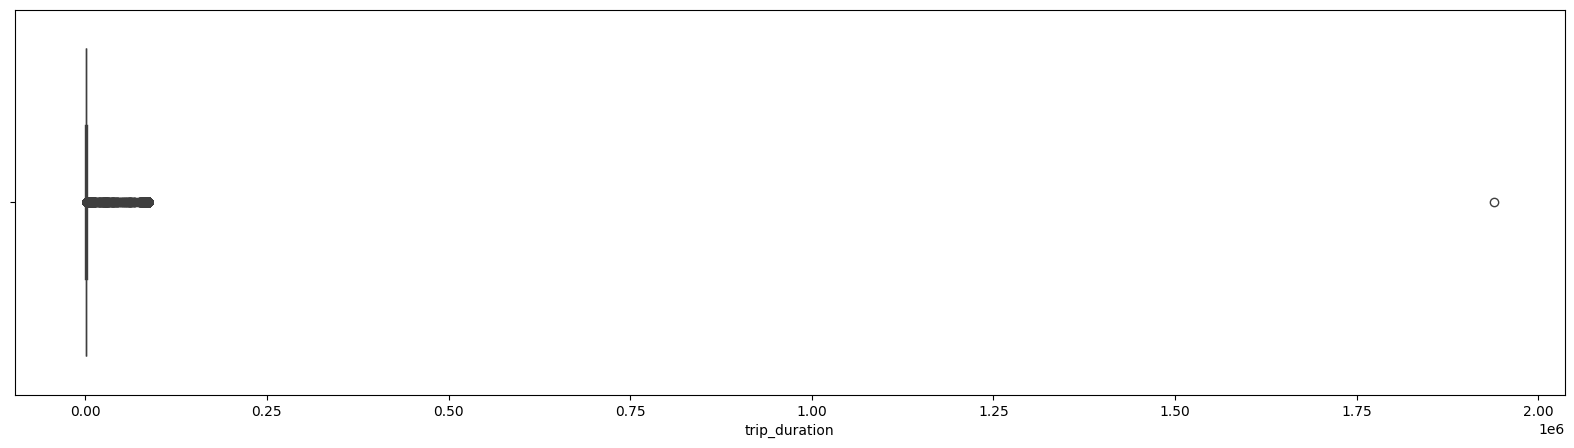

In [16]:
plt.figure(figsize=(20,5))
sns.boxplot(x=df['trip_duration'])
plt.xlabel('trip_duration')
plt.show()


* Some trip durations are over 100000 seconds which are clear outliers and should be removed.
* There are some durations with as low as 1 second. which points towards trips with 0 km distance.
* Major trip durations took between 10-20 mins to complete.
* Mean and mode are not same which shows that trip duration distribution is skewed towards right

Let's analyze more

In [17]:
df.trip_duration.groupby(pd.cut(df.trip_duration, np.arange(1,max(df.trip_duration),3600))).count()

C:\Users\parth\AppData\Local\Temp\ipykernel_14388\2860629879.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.trip_duration.groupby(pd.cut(df.trip_duration, np.arange(1,max(df.trip_duration),3600))).count()


trip_duration
(1, 3601]             723253
(3601, 7201]            4964
(7201, 10801]             61
(10801, 14401]            15
(14401, 18001]             2
                       ...  
(1918801, 1922401]         0
(1922401, 1926001]         0
(1926001, 1929601]         0
(1929601, 1933201]         0
(1933201, 1936801]         0
Name: trip_duration, Length: 538, dtype: int64

* These trips ran for more than 20 days, which seems unlikely by the distance travelled.
* All the trips are taken by vendor 1 which points us to the fact that this vendor might allows much longer trip for outstations.
* All these trips are either taken on Tuesday's in 1st month or Saturday's in 2nd month. There might be some relation with the weekday, pickup location, month and the passenger.
* But they fail our purpose of correct prediction and bring inconsistencies in the algorithm calculation.

Let's visualize the number of trips taken in slabs of 0-10, 20-30 ... minutes respectively

C:\Users\parth\AppData\Local\Temp\ipykernel_14388\919114996.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.trip_duration.groupby(pd.cut(df.trip_duration, np.arange(1,7200,600))).count().plot(kind='barh',figsize = (18,5))


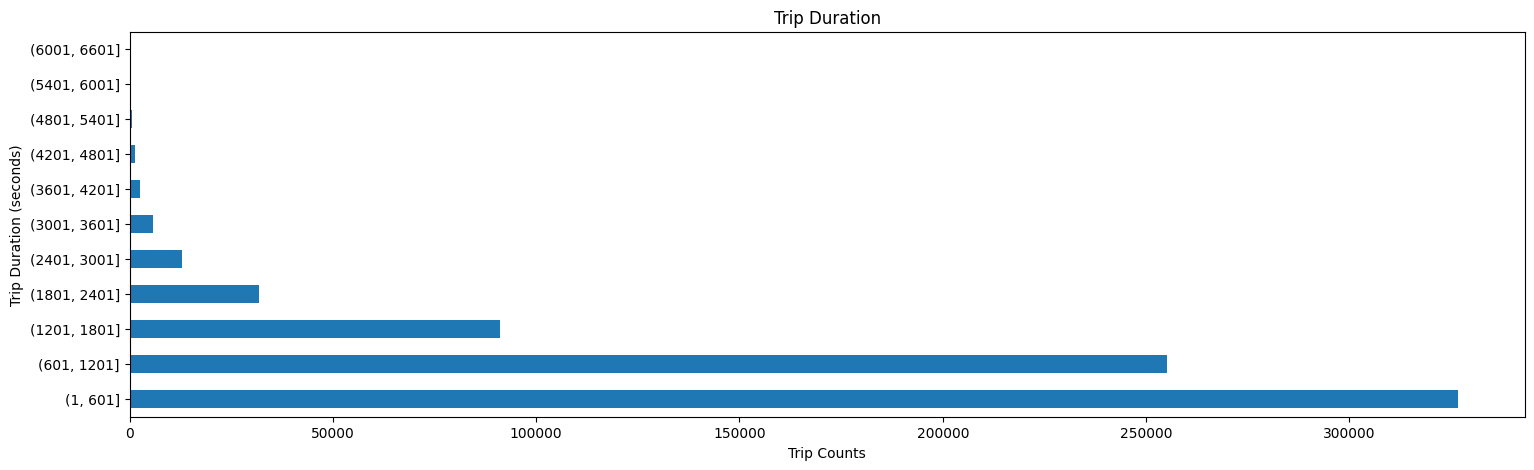

In [18]:
df.trip_duration.groupby(pd.cut(df.trip_duration, np.arange(1,7200,600))).count().plot(kind='barh',figsize = (18,5))
plt.title('Trip Duration')
plt.xlabel('Trip Counts')
plt.ylabel('Trip Duration (seconds)')
plt.show()

We can observe that most of the trips took 0 - 30 mins to complete i.e. approx 1800 secs.


**5.Distance**

Let's now have a look on the distribution of the distance across the different types of rides.

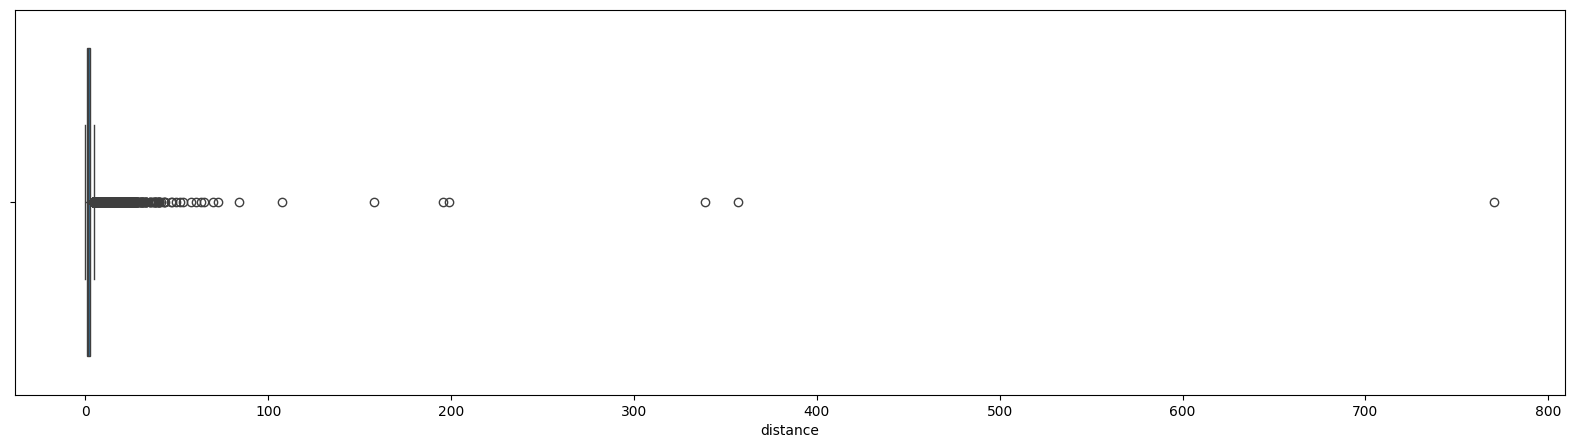

In [19]:
plt.figure(figsize=(20,5))
sns.boxplot(x=df['distance'])
plt.xlabel('distance')
plt.show()


Interesting find:
* There some trips with over 60 miles distance.
* Some of the trips distance value is 0 miles.

Observations:
* mean distance travelled is approx 2.1 miles.

In [20]:
print(f"There are {df.distance[df.distance == 0 ].count()} trip records with 0 miles distance")

There are 2901 trip records with 0 miles distance


Around 3K trip record with distance equal to 0. Below are some possible explanation for such records.
* Customer changed mind and cancelled the journey just after accepting it.
* Software didn't recorded dropoff location properly due to which dropoff location is the same as the pickup location.
* Issue with GPS tracker while the journey is being finished.
* Driver cancelled the trip just after accepting it due to some reason. So the trip couldn't start
* Or some other issue with the software itself which a technical guy can explain

There is some serious inconsistencies in the data where drop off location is same as the pickup location. We can't think off imputing the distance values considering a correlation with the duration because the dropoff_location coordinates would not be inline with the distance otherwise. We will look more to it in bivariate analysis with the Trip duration.

C:\Users\parth\AppData\Local\Temp\ipykernel_14388\2861754717.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.distance.groupby(pd.cut(df.distance, np.arange(0,80,10))).count().plot(kind='barh',figsize = (19,4))


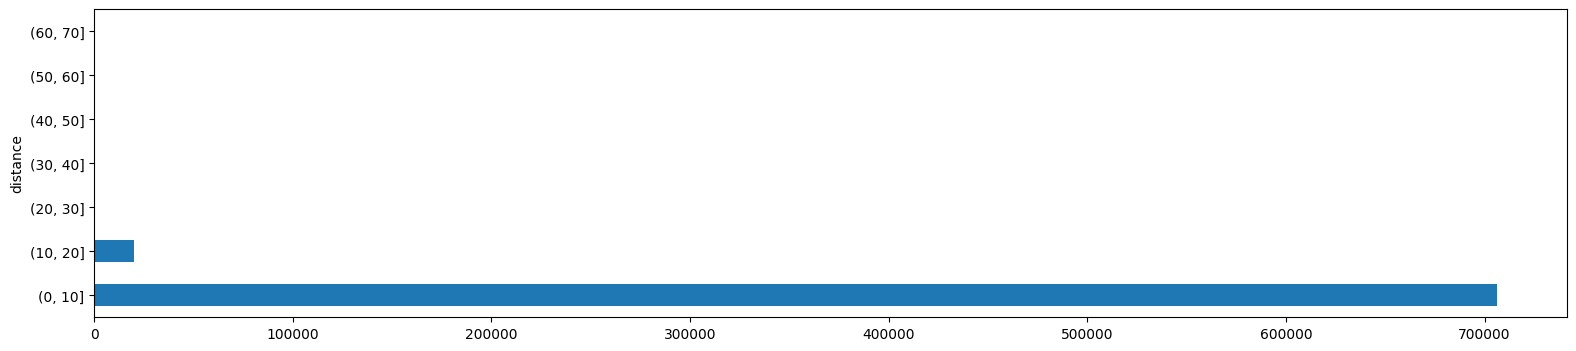

In [21]:
df.distance.groupby(pd.cut(df.distance, np.arange(0,80,10))).count().plot(kind='barh',figsize = (19,4))
plt.show()

From the above observation, it is clear that the majority of rides fall within the 1–10 mile range, with a smaller portion ranging from 10–30 miles. The bars representing other distance ranges are barely visible, as the number of trips in those categories is significantly lower in comparison.


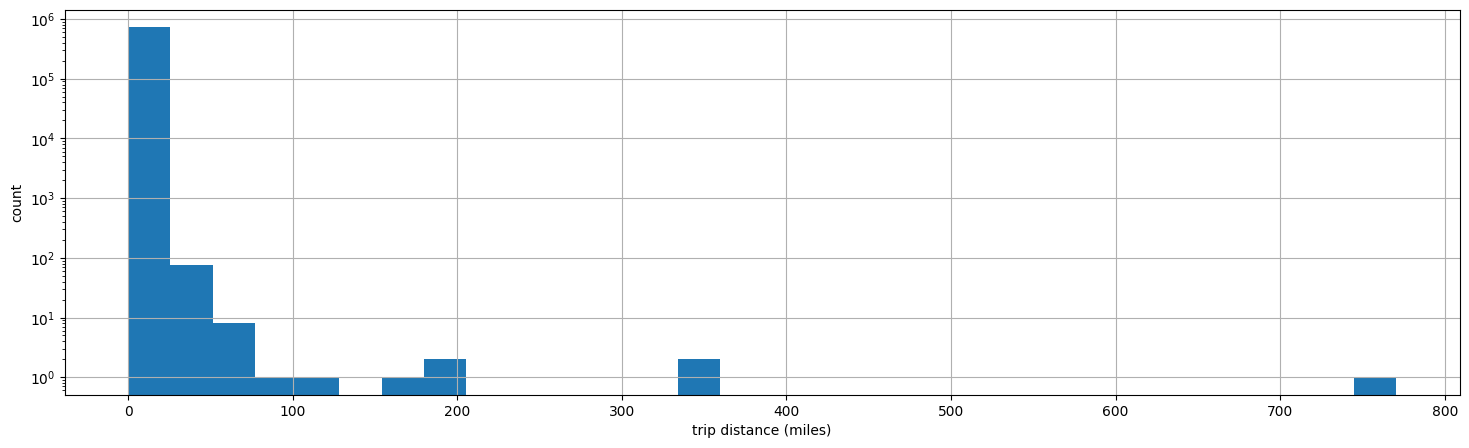

In [22]:
ax = df['distance'].hist(bins=30, figsize=(18,5))
ax.set_yscale('log')
ax.set_xlabel("trip distance (miles)")
ax.set_ylabel("count")
plt.show()

Based on the distribution of trip distances and the fact that driving across the entirety of New York City covers approximately 30 miles, we chose 30 miles as the threshold to categorize trips as either short or long distance.


In [23]:
df_short = df[df.distance <= 30].count()
df_long = df[df.distance > 30].count()
print(f"Short Trips: {df_short[0]} records in total.\nLong Trips: {df_long[0]} records in total.")

Short Trips: 729268 records in total.
Long Trips: 54 records in total.


C:\Users\parth\AppData\Local\Temp\ipykernel_14388\3735405550.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Short Trips: {df_short[0]} records in total.\nLong Trips: {df_long[0]} records in total.")


**6.Speed**

Speed is a function of distance and time. Let's visualize speed in different trips.

Maximum speed limit in NYC is as follows:

* 25 mph in urban area
* 65 mph on controlled state highways

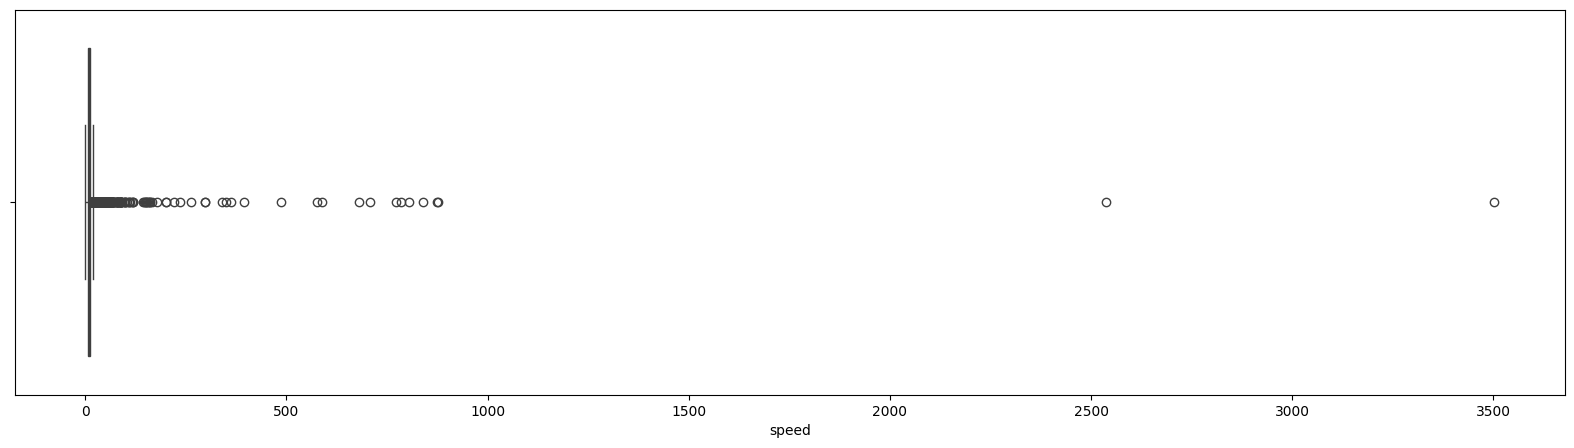

In [24]:
plt.figure(figsize = (20,5))
sns.boxplot(x =df['speed'])
plt.xlabel('speed')
plt.show()

* Many trips were done at a speed of over 125 mile/h. Going SuperSonic..!!

Let's remove them and focus on the trips which were done at less than 65 mile/h as per the speed limits

C:\Users\parth\AppData\Local\Temp\ipykernel_14388\3038680094.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.speed.groupby(pd.cut(df.speed, np.arange(0,65,10))).count().plot(kind = 'barh',figsize = (19,5))


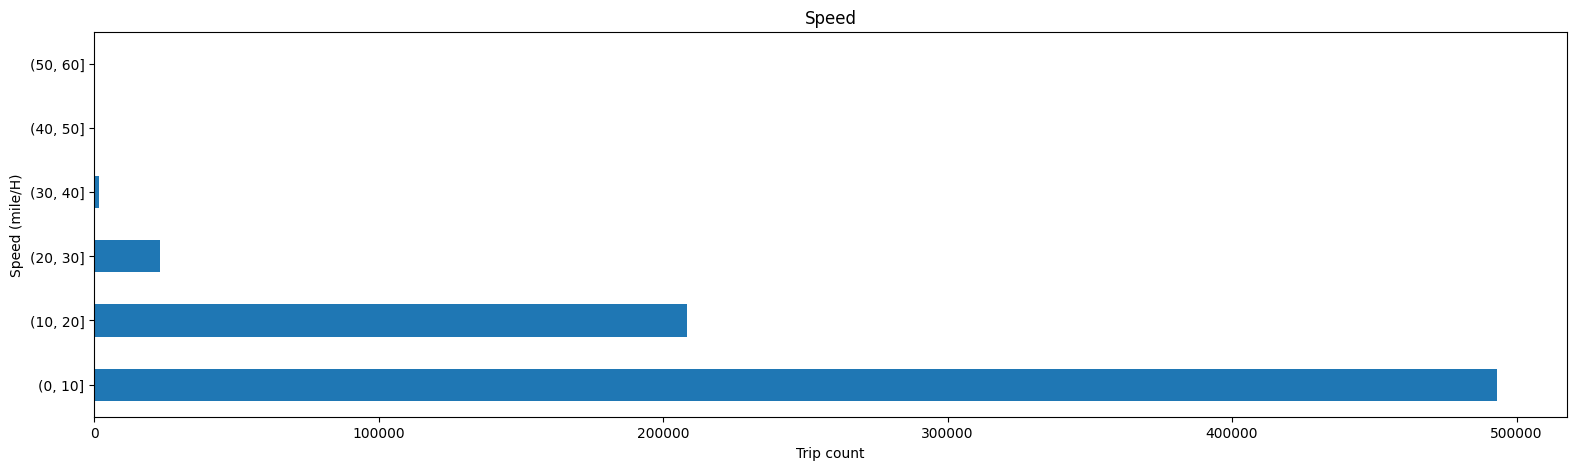

In [25]:
df = df[df.speed <= 65]
df.speed.groupby(pd.cut(df.speed, np.arange(0,65,10))).count().plot(kind = 'barh',figsize = (19,5))
plt.xlabel('Trip count')
plt.ylabel('Speed (mile/H)')
plt.title('Speed')
plt.show()

* Trips exceeding 15 miles per hour are considered outliers; however, they cannot be disregarded since they fall well within the maximum speed limit of 65 miles per hour on state-controlled highways.

* The majority of trips occur within a speed range of 6–12 miles per hour, with an average speed of approximately 8 miles per hour. This graph clearly supports our assumption that most trips were taken at speeds between 6 and 12 miles per hour.


**7.Total trips Per Hour**

Let's take a look at the distribution of the pickups across the 24 hour time scale.

In [26]:
def clock(ax, radii, title, color):
    N = 24
    bottom = 2

    # create theta for 24 hours
    theta = np.linspace(0.0, 2 * np.pi, N, endpoint=False)


    # width of each bin on the plot
    width = (2*np.pi) / N
    
    bars = ax.bar(theta, radii, width=width, bottom=bottom, color=color, edgecolor="#999999")

    # set the lable go clockwise and start from the top
    ax.set_theta_zero_location("N")
    # clockwise
    ax.set_theta_direction(-1)

    # set the label
    ax.set_xticks(theta)
    ticks = ["{}:00".format(x) for x in range(24)]
    ax.set_xticklabels(ticks)
    ax.set_title(title)

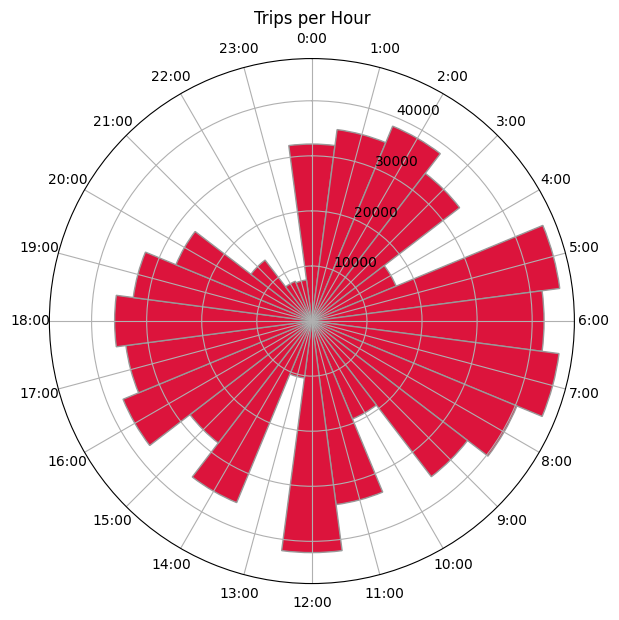

In [27]:
plt.figure(figsize = (15,15))
ax = plt.subplot(2,2,1, polar=True)
    # make the histogram that bined on 24 hour
radii = np.array(df['pickup_hour'].value_counts(sort = False).tolist(), dtype="int64")
# radii = np.array(df['pickup_hour'].value_counts().tolist(), dtype="int64")
title = "Trips per Hour"
clock(ax, radii, title, "#dc143c")

**Late Night/Early Morning (11:00 PM - 6:00 AM):** The chart shows minimal trip activity during these hours, which is expected as most people are sleeping and there's less urban activity.

**Mid-Morning to Early Afternoon (10:00 AM - 3:00 PM):** Relatively lower but steady demand during these hours, likely representing business trips, appointments, and non-commuter travel.


**8.Total trips per weekday**

Let's take a look now at the distribution of taxi pickups across the week.

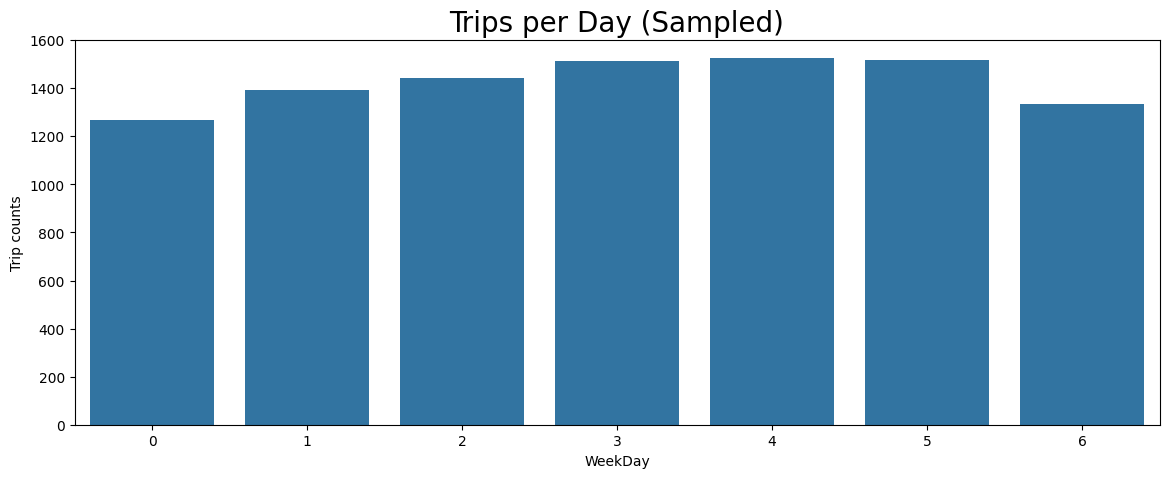

In [28]:
# Sample 10,000 rows for plotting
sample_df = df.sample(n=10000, random_state=42)

plt.figure(figsize=(14,5))
sns.countplot(x=sample_df.weekday_num)
plt.xlabel('WeekDay')
plt.ylabel('Trip counts')
plt.title('Trips per Day (Sampled)', fontsize=20)
plt.show()


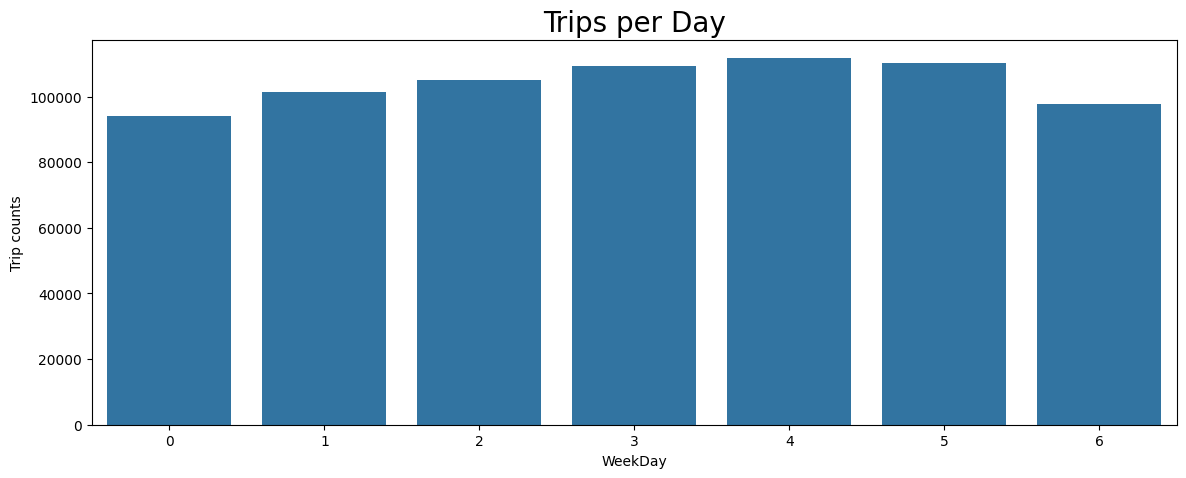

In [29]:
weekday_counts = df['weekday_num'].value_counts().sort_index()
plt.figure(figsize=(14,5))
sns.barplot(x=weekday_counts.index, y=weekday_counts.values)
plt.xlabel('WeekDay')
plt.ylabel('Trip counts')
plt.title('Trips per Day', fontsize=20)
plt.show()


* Here, we observe a rising trend in taxi pickups from Monday through Friday, followed by a decline from Saturday to Monday. This pattern is expected, as many office-goers prefer to stay home and rest during the weekend.

Let’s delve deeper to examine the hourly pickup patterns across each day of the week.


**9.Total trips per month**

Let's take a look at the trip distribution across the months to understand if there is any diffrence in the taxi pickups in different months

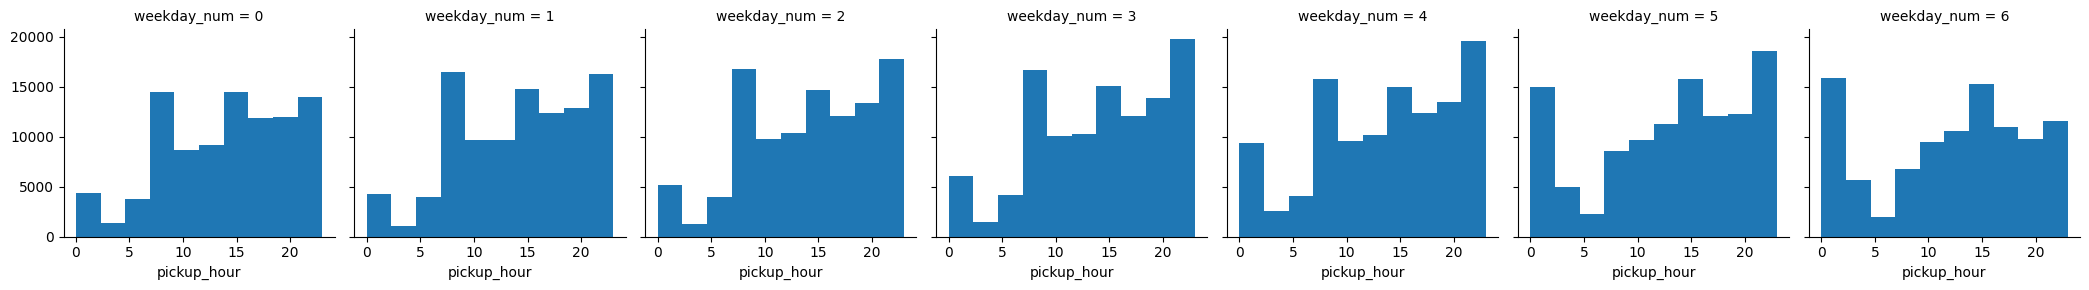

In [30]:
n = sns.FacetGrid(df, col='weekday_num')
n.map(plt.hist, 'pickup_hour')
plt.show()

* Taxi pickups show a noticeable increase during the late-night hours over the weekend, likely due to more outstation trips or late-night leisure activities.

* Interestingly, early morning pickups (before 5 AM) also rise over the weekend, while pickups during typical office hours (after 7 AM) decline, which is expected given the reduced work-related travel.

* Pickups around 3 PM (15:00 hours) appear to remain consistent throughout the week.


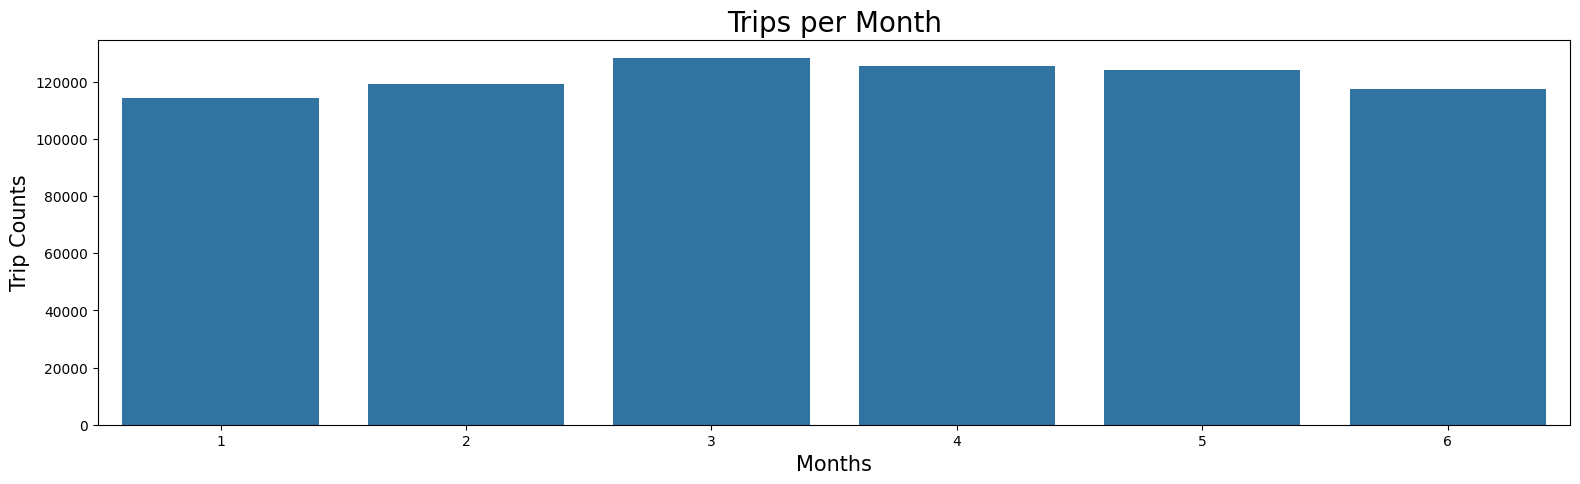

In [31]:
month_counts = df['month'].value_counts().sort_index()

plt.figure(figsize=(19,5))
sns.barplot(x=month_counts.index, y=month_counts.values)
plt.ylabel('Trip Counts', fontsize=15)
plt.xlabel('Months', fontsize=15)
plt.title('Trips per Month', fontsize=20)
plt.show()


There is a fairly balanced distribution of taxi pickups across the months. The distribution could have been even more uniform if we hadn't excluded inconsistent records during our univariate analysis.


**Bivariate Analysis**

Bivariate analysis is used to find out if there is a relationship between two sets of values. It usually involves the variables X and Y.

**1.Trip Duration per hour**

We need to aggregate the total trip duration to plot it agaist the month. The aggregation measure can be anything like sum, mean, median or mode for the duration. Since we already did the outlier analysis, so we can take the mean to visualize the pattern which should not result in the bias of the general trend.

Lets take a look.

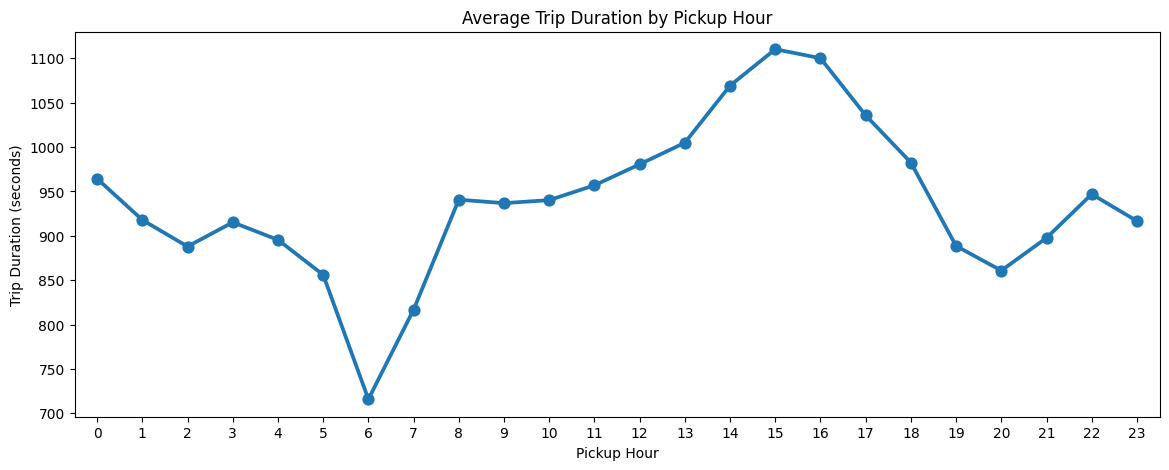

In [32]:
plt.figure(figsize=(14,5))
group1 = df.groupby('pickup_hour').trip_duration.mean()
sns.pointplot(x=group1.index, y=group1.values)
plt.ylabel('Trip Duration (seconds)')
plt.xlabel('Pickup Hour')
plt.title('Average Trip Duration by Pickup Hour')
plt.show()


* The average trip duration is lowest around 6 AM, likely due to minimal traffic on the roads at that time. It tends to peak around 3 PM when the streets are typically busier.

* Overall, the average trip duration remains relatively consistent during the early morning hours (before 6 AM) and the late evening hours (after 6 PM).


**2.Trip duration per WeekDay**

Let's now analyze the pattern of trip duration during the week.

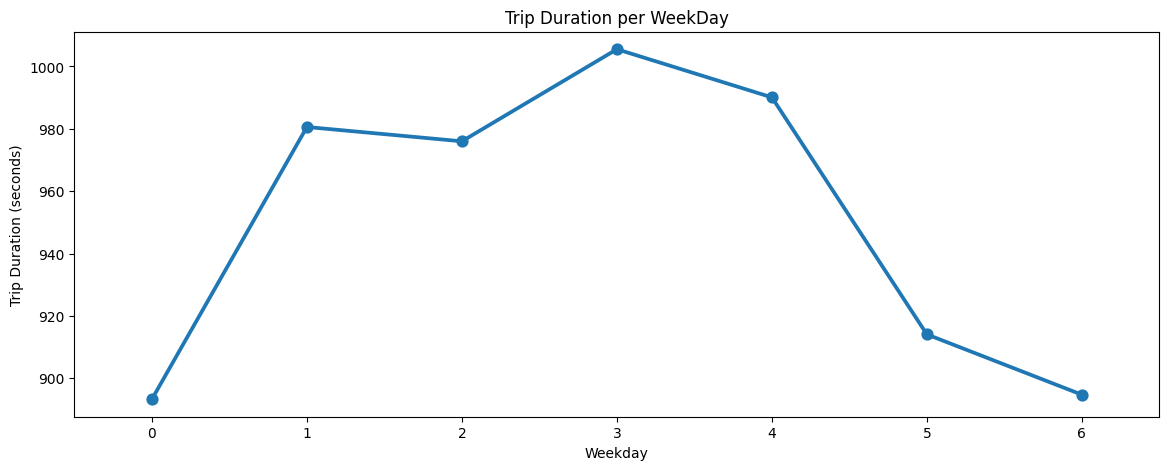

In [33]:
plt.figure(figsize = (14,5))
group2 = df.groupby('weekday_num').trip_duration.mean()
sns.pointplot(x=group2.index,y= group2.values)
plt.ylabel('Trip Duration (seconds)')
plt.xlabel('Weekday')
plt.title('Trip Duration per WeekDay')
plt.show()

Trip duration appears to be fairly evenly distributed throughout the week, generally falling within the 0–1000 minute range, with only slight variations in duration. Notably, Thursday shows the longest average trip duration compared to the other days.


**3.Trip duration per Month**

Let's take a look at the trip duration pattern with respect to the different months.

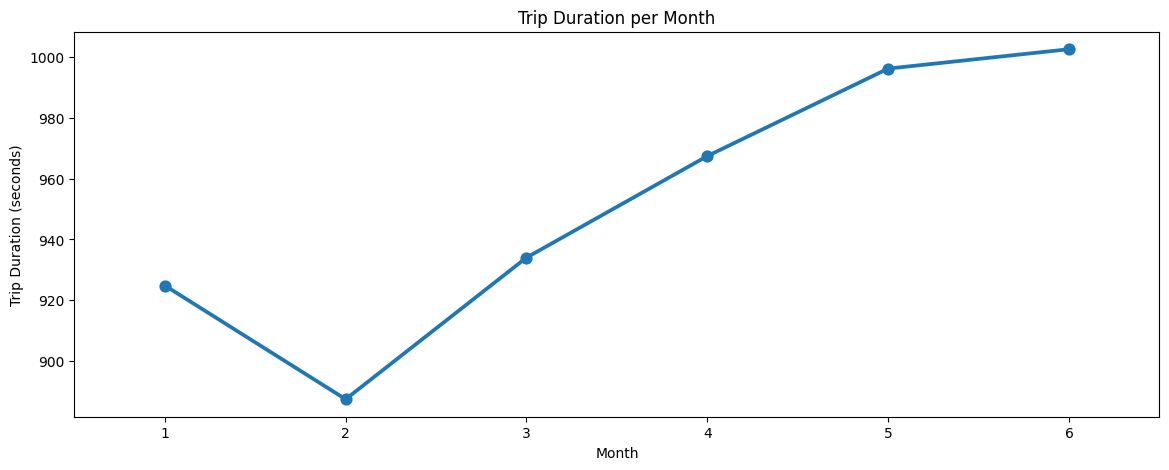

In [34]:
plt.figure(figsize = (14,5))
group3 = df.groupby('month').trip_duration.mean()
sns.pointplot(x=group3.index,y= group3.values)
plt.ylabel('Trip Duration (seconds)')
plt.xlabel('Month')
plt.title('Trip Duration per Month')
plt.show()

The line chart showing "Trip Duration per Month" reveals a clear seasonal trend:

* February (Month 2) shows the lowest average trip duration (~400 seconds)

* Steady increase from February through June, with trip durations rising to approximately 950-1000 seconds

* This pattern suggests winter months have shorter trips while spring/summer months have longer trips

**4.Trip duration per vendor**

We can also look at the average difference between the trip duration for each vendor. However we do know that vendor 2 has larger share of the market. Let's visualize.

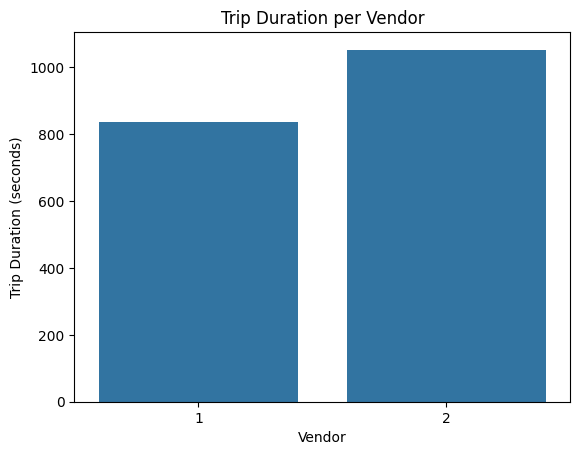

In [35]:
group4 = df.groupby('vendor_id').trip_duration.mean()
sns.barplot(x=group4.index, y = group4.values)
plt.ylabel('Trip Duration (seconds)')
plt.xlabel('Vendor')
plt.title('Trip Duration per Vendor')
plt.show()

Average trip duration  for  vendor 2 is higher than vendor 1 by around 200 seconds.

**5.Distance per hour**

Now, let us check how the distance is distributed against different variables. We know that trip distance must be more or less proportional to the trip duration if we ignore general traffic and other stuff on the road. Let's visualize this for each hour now.

Since we have already done the outlier analysis for this variable as well. We can take the mean as aggregate measure for our visualizations.

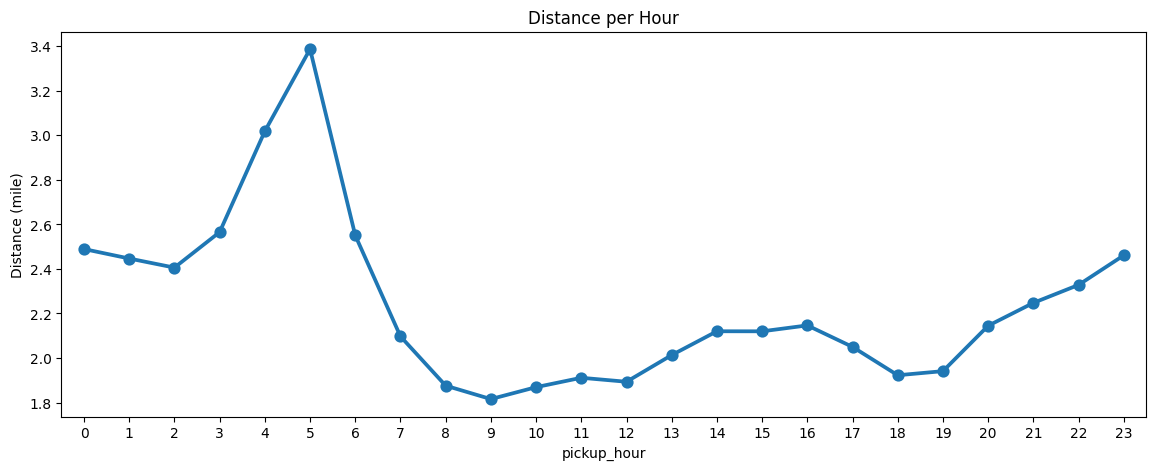

In [36]:
plt.figure(figsize = (14,5))
group5 = df.groupby('pickup_hour').distance.mean()
sns.pointplot(x=group5.index, y= group5.values)
plt.ylabel('Distance (mile)')
plt.title('Distance per Hour')
plt.show()

Trip distances are highest during the early morning hours, which may be attributed to factors such as:

* Outstation trips typically taken during weekends
* Longer rides to the city airport, which is situated on the outskirts

From morning to evening, trip distances remain relatively consistent, averaging around 2 to 2.5 miles. However, distances begin to gradually increase during the evening and continue rising through the late-night hours until around 5 AM, after which they drop sharply toward the morning.


**6.Distance per WeekDay**

Let's analyze the average trip distance covered on each day of the week.

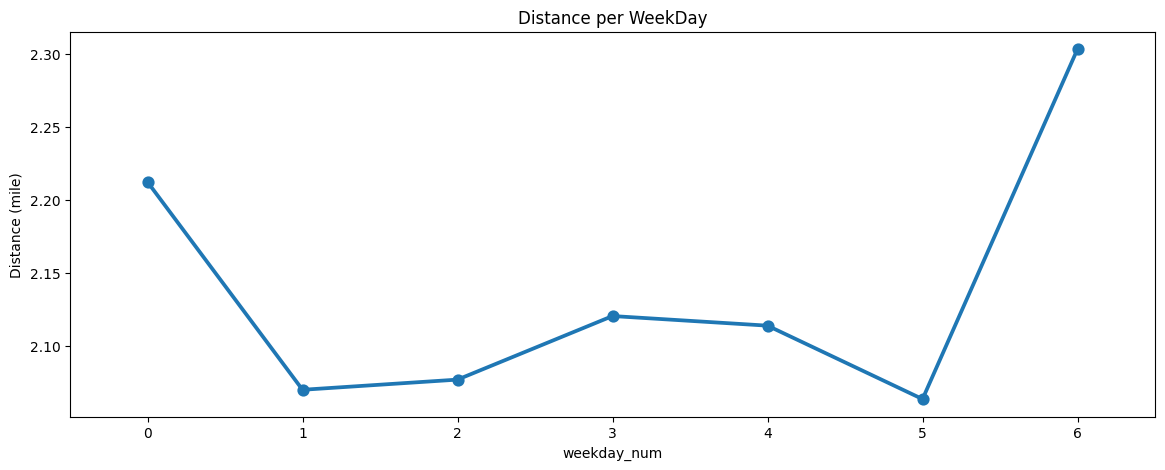

In [37]:
plt.figure(figsize = (14,5))
group6 = df.groupby('weekday_num').distance.mean()
sns.pointplot(x=group6.index,y = group6.values)
plt.ylabel('Distance (mile)')
plt.title('Distance per WeekDay')
plt.show()

Overall, the trip distances are fairly evenly distributed, with the average distance hovering around 2 miles per hour. Sunday stands out with slightly higher averages, likely due to outstation trips or late-night rides to the airport.


**7.Distance per Month**

Now we will look at the average trip distance covered per month.

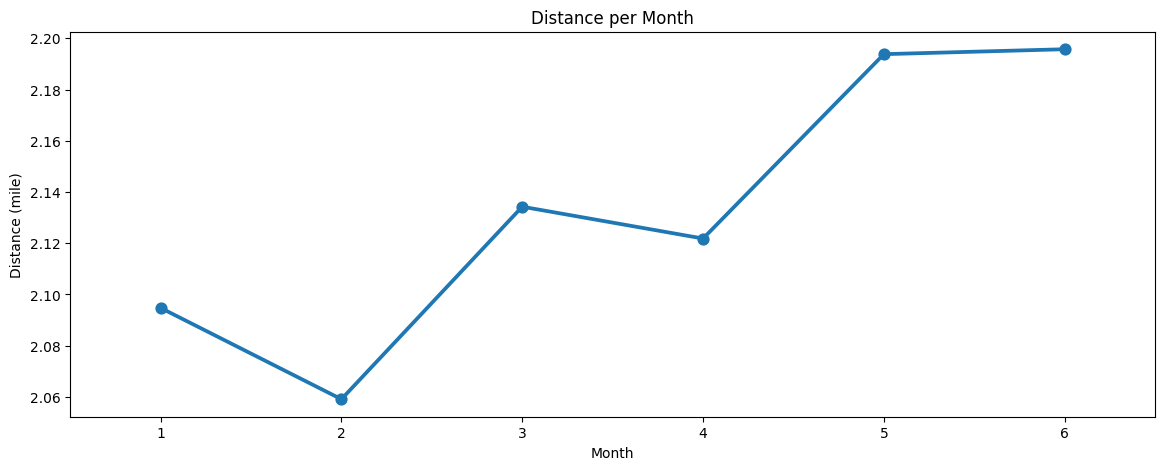

In [38]:
plt.figure(figsize = (14,5))
group7 = df.groupby('month').distance.mean()
sns.pointplot(x = group7.index,y = group7.values)
plt.ylabel('Distance (mile)')
plt.xlabel('Month')
plt.title('Distance per Month')
plt.show()

The "Distance per Month" chart reveals a clear seasonal trend in trip distances:

* February (Month 2) shows the shortest average distances (~2.06 miles)

* Steady increase from February through June, reaching approximately 2.18-2.19 miles

* This indicates winter months have shorter trips while spring/summer months have longer trips

**8.Distance per Vendor**

Let's check how both the vendors have covered the average distance during the trips

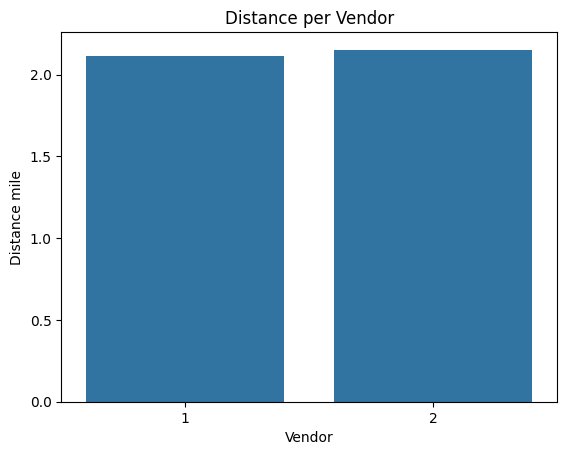

In [39]:
group8 = df.groupby('vendor_id').distance.mean()
sns.barplot(x = group8.index, y = group8.values)
plt.ylabel("Distance mile")
plt.xlabel("Vendor")
plt.title('Distance per Vendor')
plt.show()

Both vendors exhibit the same behaviour

**9.Distance v/s Trip duration**

Let's visualize the relationship between Distance covered and respective trip duration.

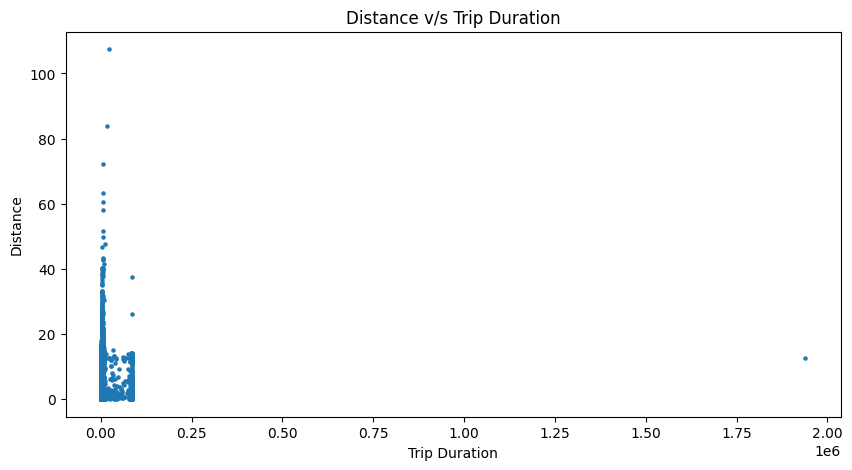

In [40]:
plt.figure(figsize = (10,5))
plt.scatter(df.trip_duration, df.distance , s=5, alpha=1)
plt.ylabel('Distance')
plt.xlabel('Trip Duration')
plt.title('Distance v/s Trip Duration')
plt.show()

The scatter plot reveals a strong positive correlation between distance and trip duration:

* Dense cluster of points concentrated in the lower-left region (short distances, short durations)

* Clear linear trend showing that longer distances generally correspond to longer trip durations

* Heavy concentration around 0-20 miles distance and 0-0.5 hours duration

* Few outliers with very long distances or durations, suggesting most NYC taxi trips are relatively short


**Key Insight:** The relationship follows expected physics - longer distances require more time, indicating consistent average speeds across trips.

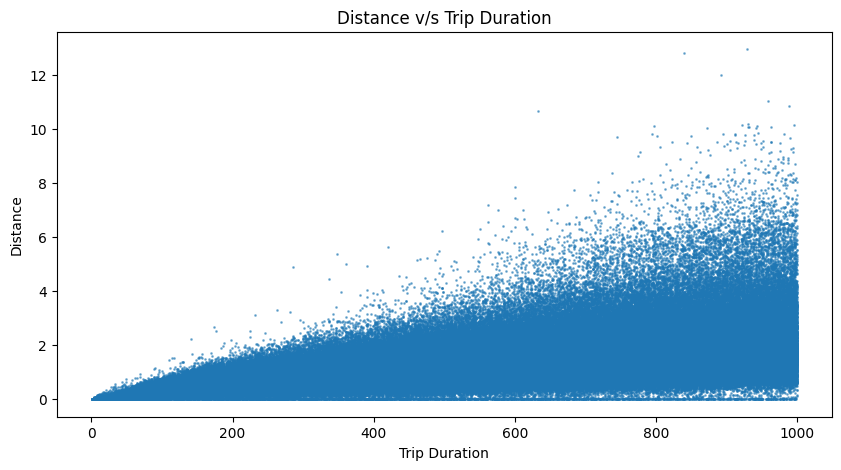

In [41]:
plt.figure(figsize = (10,5))
dur_dist = df.loc[(df.distance < 30) & (df.trip_duration < 1000), ['distance','trip_duration']]
plt.scatter(dur_dist.trip_duration, dur_dist.distance , s=1, alpha=0.5)
plt.ylabel('Distance')
plt.xlabel('Trip Duration')
plt.title('Distance v/s Trip Duration')
plt.show()

The scatter plot reveals a strong positive linear relationship between distance and trip duration:

* Dense concentration of points in the lower-left region (0-2 miles, 0-200 seconds)

* Clear linear trend showing longer distances require proportionally more time

* Consistent slope suggesting relatively uniform average speeds across NYC taxi trips

* Few extreme outliers with very long distances (>10 miles) or durations (>800 seconds)

* Average speed annotation shows approximately 10 mph, which is realistic for NYC traffic conditions

**Key Insight:** The relationship follows expected physics with good predictability - distance is a strong predictor of trip duration.

**10.Average speed per hour**

Let's look at the average speed of NYC Taxi per hour.

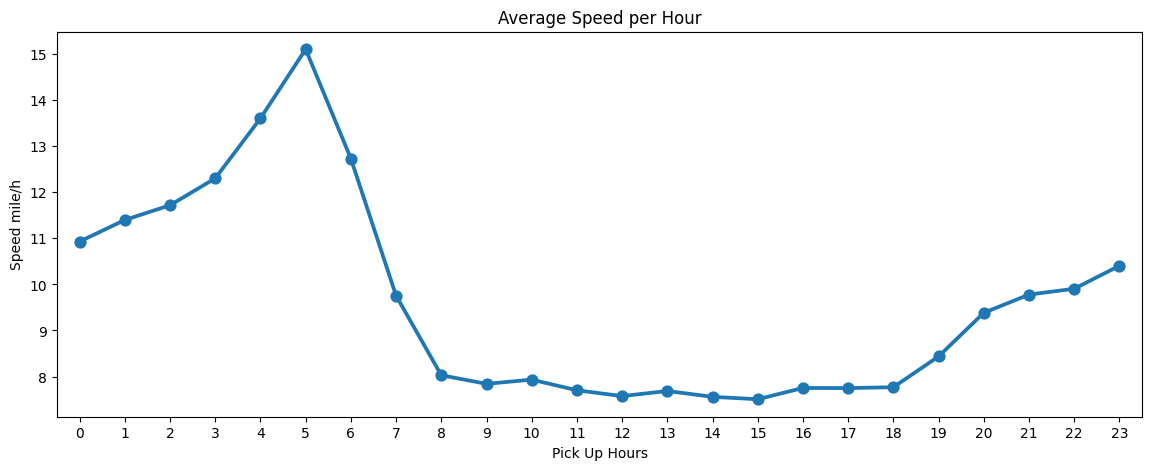

In [42]:
plt.figure(figsize = (14,5))
group9 = df.groupby('pickup_hour').speed.mean()
sns.pointplot(x = group9.index, y = group9.values)
plt.xlabel('Pick Up Hours')
plt.ylabel('Speed mile/h')
plt.title('Average Speed per Hour')
plt.show()

* The average speed trend aligns perfectly with typical expectations.

* Average speeds begin to rise after late evening and continue increasing steadily through the early morning hours. The highest average taxi speed occurs at 5 AM, after which it drops sharply as office hours approach.

* During office hours, roughly from 8 AM to 6 PM, the average taxi speed remains relatively constant.


**11.Average speed per weekday**

Let's visualize that on an average what is the speed of a taxi on any given weekday.

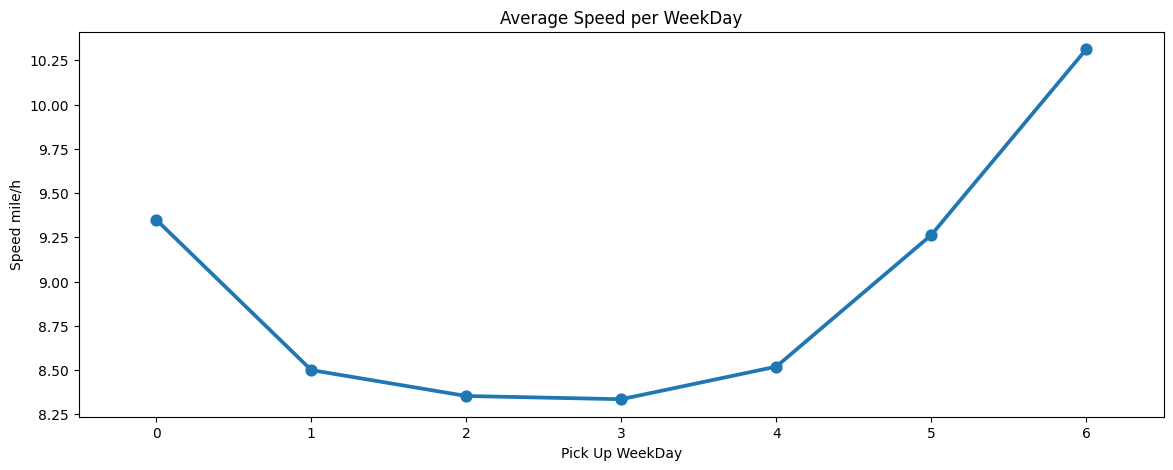

In [43]:
plt.figure(figsize = (14,5))
group10 = df.groupby('weekday_num').speed.mean()
sns.pointplot(x =group10.index, y =group10.values)
plt.xlabel('Pick Up WeekDay')
plt.ylabel('Speed mile/h')
plt.title('Average Speed per WeekDay')
plt.show()


* Average taxi speeds are higher on weekends compared to weekdays, which makes sense given the heavy traffic from office commuters and business activities during the week.

* Interestingly, Monday also shows relatively high average speeds, which is somewhat surprising since it’s typically one of the busiest days. This could be due to several factors, such as:

* Many customers returning from outstation trips early Monday morning (before 6 AM) to reach work on time.
* Passengers arriving from airports after vacations, heading to work or business early in the week.

* There may be other local factors influencing this pattern that only residents would fully understand. Additionally, we cannot rule out anomalies within the dataset, which can be difficult to detect given its large size.


**12.Passenger count per vendor**

Let's try some different metric in the series i.e. passenger count. We will plot it agaist the vendor only because it will not be much helpful to plot it against hour, weekday or month like others as the passenger count should be a whole number and not a ratio.

we will take mean as the aggregate measure because we already did the outlier analysis on this metric. So our results woudn't be affected by some extreme values. Also if we take median than it will return only 1 because majorty of the trips have been taken by single passenger. Let's take a look about it's distribution.

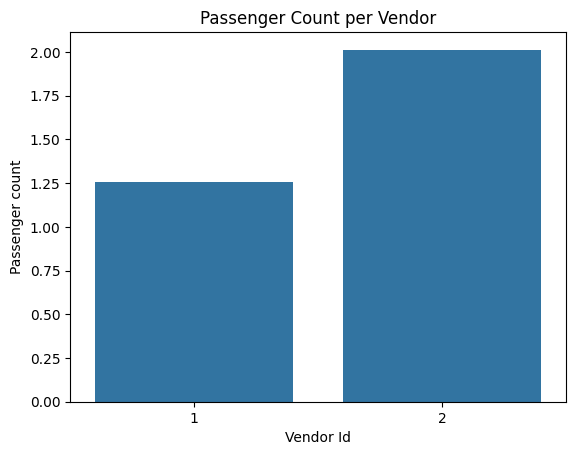

In [44]:
group9 = df.groupby('vendor_id').passenger_count.mean()
sns.barplot(x =group9.index, y=group9.values)
plt.ylabel('Passenger count')
plt.xlabel('Vendor Id')
plt.title('Passenger Count per Vendor')
plt.show()

There is a clear difference between the two operators in terms of average passenger count per trip. Vendor 2’s trips typically have around 2 passengers, whereas Vendor 1’s trips mostly carry just 1 passenger. Let’s break this down further.

* It appears that Vendor 2 primarily serves larger vehicles, including minivans. Apart from single-passenger trips, Vendor 2 dominates in trips with multiple passengers, which likely contributes to its larger market share.


**13.Pick Up Points v/s Dropoff Points**

Here we take a look at the spread of Pickup co-ordinates and Drop-off co-ordinates across city

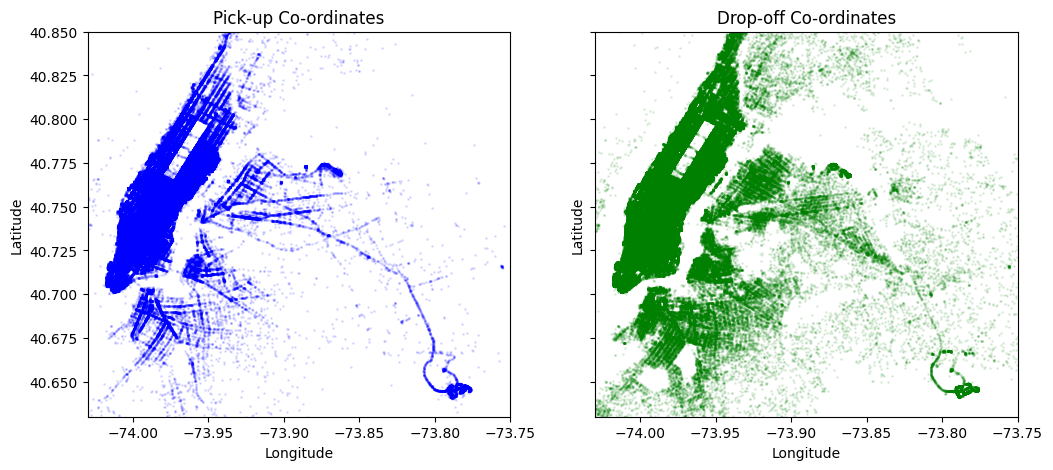

In [45]:
city_long_border = (-74.03, -73.75)
city_lat_border = (40.63, 40.85)
fig, ax = plt.subplots(ncols=2, sharex=True, sharey=True,figsize = (12,5))
ax[0].scatter(df['pickup_longitude'].values, df['pickup_latitude'].values,
color='blue', s=1, label='train', alpha=0.1)
ax[1].scatter(df['dropoff_longitude'].values, df['dropoff_latitude'].values,
color='green', s=1, label='train', alpha=0.1)
ax[1].set_title('Drop-off Co-ordinates')
ax[0].set_title('Pick-up Co-ordinates')
ax[0].set_ylabel('Latitude')
ax[0].set_xlabel('Longitude')
ax[1].set_ylabel('Latitude')
ax[1].set_xlabel('Longitude')
plt.ylim(city_lat_border)
plt.xlim(city_long_border)
plt.show()

* In the pickup plot, the majority of pickups are concentrated in the Manhattan area, indicating that Manhattan is a densely populated and popular pickup location.

* In contrast, drop-off locations are more widely distributed. This aligns with our distance analysis, where the average trip distance is around 2.1 miles, explaining the high concentration of drop-offs within Manhattan itself.


**Clustering**

In [46]:
coords = np.vstack((df[['pickup_latitude', 'pickup_longitude']].values,
                    df[['dropoff_latitude', 'dropoff_longitude']].values))

C:\Python312\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but MiniBatchKMeans was fitted without feature names
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but MiniBatchKMeans was fitted without feature names
  warnings.warn(


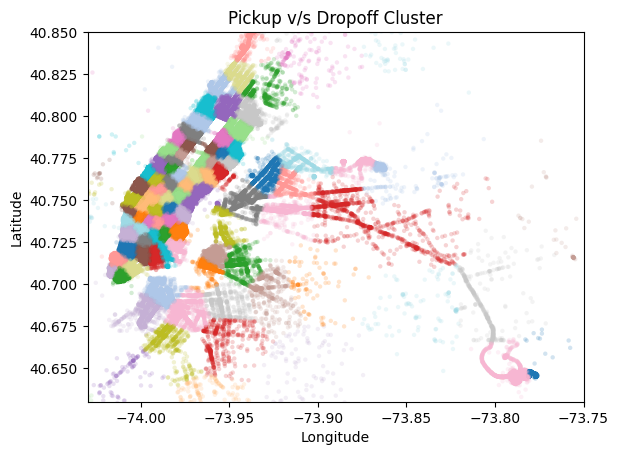

In [47]:
from sklearn.cluster import MiniBatchKMeans
sample_ind = np.random.permutation(len(coords))[:500000]
kmeans = MiniBatchKMeans(n_clusters=100, batch_size=10000).fit(coords[sample_ind])
df.loc[:, 'pickup_cluster'] = kmeans.predict(df[['pickup_latitude', 'pickup_longitude']])
df.loc[:, 'dropoff_cluster'] = kmeans.predict(df[['dropoff_latitude', 'dropoff_longitude']])
fig, ax = plt.subplots(ncols=1, nrows=1)
ax.scatter(df.pickup_longitude.values, df.pickup_latitude.values, s=10, lw=0,
           c=df.pickup_cluster.values, cmap='tab20', alpha=0.2)
ax.set_xlim(city_long_border)
ax.set_ylim(city_lat_border)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Pickup v/s Dropoff Cluster')
plt.show()

The clustering results closely resemble the way New York City is traditionally divided into neighborhoods. For example, the Upper East and Upper West Sides of Central Park appear as distinct clusters in gray and pink, respectively. West Midtown is shown in blue, Chelsea and the West Village in brown, the Downtown area in blue, and East Village and SoHo in purple.

The airports, JFK and LaGuardia, each form their own separate clusters, as do Queens and Harlem. Brooklyn is split into two clusters, while the Bronx has too few rides to be distinguished separately from Harlem.


**Feature Engineering**

**1.Feature Selection**

We will use technique to select the best features to train our model.

Here the biggest question is which columns are useful for model train

In [48]:
df.dtypes

id                            object
vendor_id                      int64
pickup_datetime       datetime64[ns]
dropoff_datetime      datetime64[ns]
passenger_count                int64
pickup_longitude             float64
pickup_latitude              float64
dropoff_longitude            float64
dropoff_latitude             float64
store_and_fwd_flag            object
trip_duration                  int64
weekday                       object
month                          int32
weekday_num                    int32
pickup_hour                    int32
distance                     float64
speed                        float64
pickup_cluster                 int32
dropoff_cluster                int32
dtype: object

* id column has unique values which means its no use to take id in model training
* Columns such as pickup_datetime,dropoff_datetime has object dtype and the values are datetype which may not able to evaluate by model which can affect in accuracy.
* Therefore pickup_datetime is been converted into weekday, month, weekday_num, pickup_hour
* pickup_longitude,pickup_latitude and dropoff_longitude,dropoff_latitude are the columns which are dependent on each other.
* This columns does not mean much if pass as individual columns.
* Other than this store_and_fwd_flag is just a service info column.
* Excluding this columns the other columns such as vendor_id, passenger_count, distance, speed correlate with duration which can be used in model train.

In [49]:
df.shape

(729242, 19)

In [50]:
x = df.iloc[:, [1, 4, 11, 12, 14, 15, 16, 17, 18]].values
y = df.iloc[:,10].values
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state = 7294)

In [51]:
cols_to_convert = ['trip_duration', 'distance', 'passenger_count']
for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')


In [52]:
from scipy.stats import pearsonr

correlations = {}
target = 'trip_duration'
features = ['distance', 'pickup_hour', 'weekday_num', 'month', 'passenger_count']

for f in features:
    x1 = df[f].values
    x2 = df[target].values
    key = f + ' vs ' + target
    correlations[key] = pearsonr(x1, x2)[0]  # [0] gives just the correlation coefficient

# Convert to DataFrame for display
import pandas as pd
data_correlations = pd.DataFrame(correlations, index=['Value']).T
data_correlations = data_correlations.loc[data_correlations['Value'].abs().sort_values(ascending=False).index]
print(data_correlations)


                                  Value
distance vs trip_duration          0.14
passenger_count vs trip_duration   0.01
month vs trip_duration             0.01
pickup_hour vs trip_duration       0.00
weekday_num vs trip_duration      -0.00


Strongest Predictor:

* Distance vs trip_duration: 0.14 - This is the highest correlation, confirming that distance is the most important factor in determining trip duration, though the correlation is relatively weak

Minimal Predictive Power:

* Passenger_count vs trip_duration: 0.01 - Almost no correlation, suggesting the number of passengers has negligible impact on trip duration

* Month vs trip_duration: 0.01 - Seasonal factors show minimal influence on trip duration

* Pickup_hour vs trip_duration: 0.00 - Time of day shows no correlation with trip duration

* Weekday_num vs trip_duration: -0.00 - Day of week has virtually no relationship with trip duration

**2.Feature Extraction**

Split Data

In [53]:
x = df.iloc[:, [1, 4, 11, 12, 14, 15, 16]].values
y = df.iloc[:,10].values
x_train_df, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state = 7294)

In [54]:
import pandas as pd

# Convert x_train (numpy array) to DataFrame
x_train_df = pd.DataFrame(x_train)

# Now check data types
print("Data types in x_train_df:")
print(x_train_df.dtypes)



Data types in x_train_df:
0    object
1    object
2    object
3    object
4    object
5    object
6    object
7    object
8    object
dtype: object


In [55]:
import pandas as pd

# Convert x_train (numpy array) to DataFrame
x_train_df = pd.DataFrame(x_train)

# 1. Identify non-numeric columns
non_numeric_cols = x_train_df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Non-numeric columns found: {non_numeric_cols}")

# 2. Only proceed if non-numeric columns exist
if non_numeric_cols:
    x_train_encoded = x_train_df.copy()
    
    # Encode categorical columns
    for col in non_numeric_cols:
        x_train_encoded[col] = pd.factorize(x_train_encoded[col])[0]
    
    print("\nAfter encoding:")
    print(x_train_encoded.dtypes)
else:
    print("No non-numeric columns found")
    x_train_encoded = x_train_df.copy()



Non-numeric columns found: [0, 1, 2, 3, 4, 5, 6, 7, 8]

After encoding:
0    int64
1    int64
2    int64
3    int64
4    int64
5    int64
6    int64
7    int64
8    int64
dtype: object


In [56]:
from sklearn.impute import SimpleImputer
import numpy as np

# Now apply imputation to the encoded numeric data
imputer = SimpleImputer(strategy='mean')
x_train_clean = imputer.fit_transform(x_train_encoded)

# Verify cleaning worked
nan_count = np.isnan(x_train_clean).sum()
print(f"NaN count after imputation: {nan_count}")




NaN count after imputation: 0


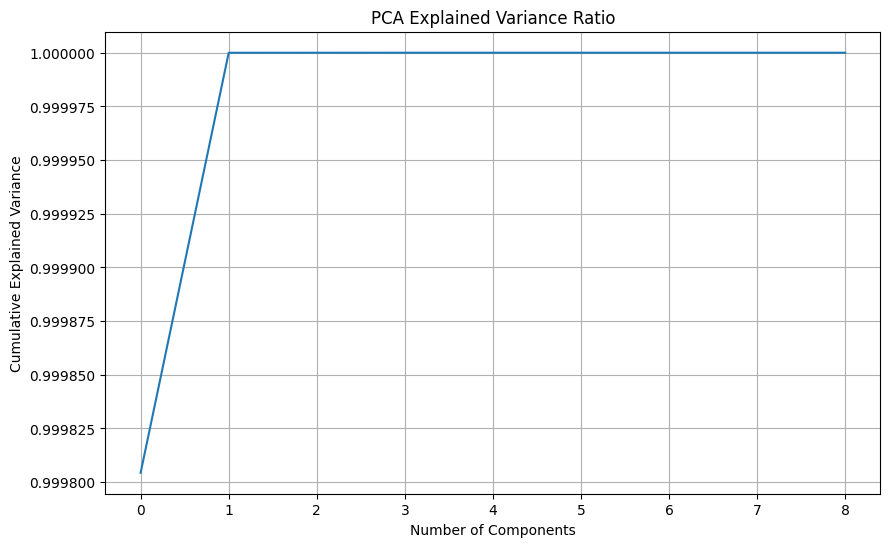

In [57]:

from sklearn.decomposition import PCA  # Add this import at the top

# Then use PCA
pca = PCA().fit(x_train_clean)

# PCA will now work without errors
pca = PCA().fit(x_train_clean)

plt.figure(figsize=(10,6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance Ratio')
plt.grid(True)
plt.show()



In [58]:
arr = np.cumsum(np.round(pca.explained_variance_ratio_, decimals=4)*100)
list(zip(range(1,len(arr)), arr))

[(1, np.float64(99.98)),
 (2, np.float64(100.0)),
 (3, np.float64(100.0)),
 (4, np.float64(100.0)),
 (5, np.float64(100.0)),
 (6, np.float64(100.0)),
 (7, np.float64(100.0)),
 (8, np.float64(100.0))]

Here, we observe that just 6 variables are sufficient to capture at least 99% of the variance in the training dataset. Therefore, we can proceed with these variables directly, and the use of PCA for dimensionality reduction is not necessary for this model.


**3.Correlation Analysis**

Correlation analysis is a statistical technique used to assess the strength and direction of the relationship between two or more continuous, numerically measured variables. It helps identify potential associations between variables. To visualize this analysis, we will use a heatmap.

A heatmap is a visual tool that displays data using color gradients to indicate the intensity of relationships or values. In the context of correlation analysis, it helps represent the strength of correlations between variables through varying color shades.ystem of color-coding to represent statistical relationship between different values.

Non-numeric columns found: [0, 1, 2, 3, 4, 5, 6, 7, 8]


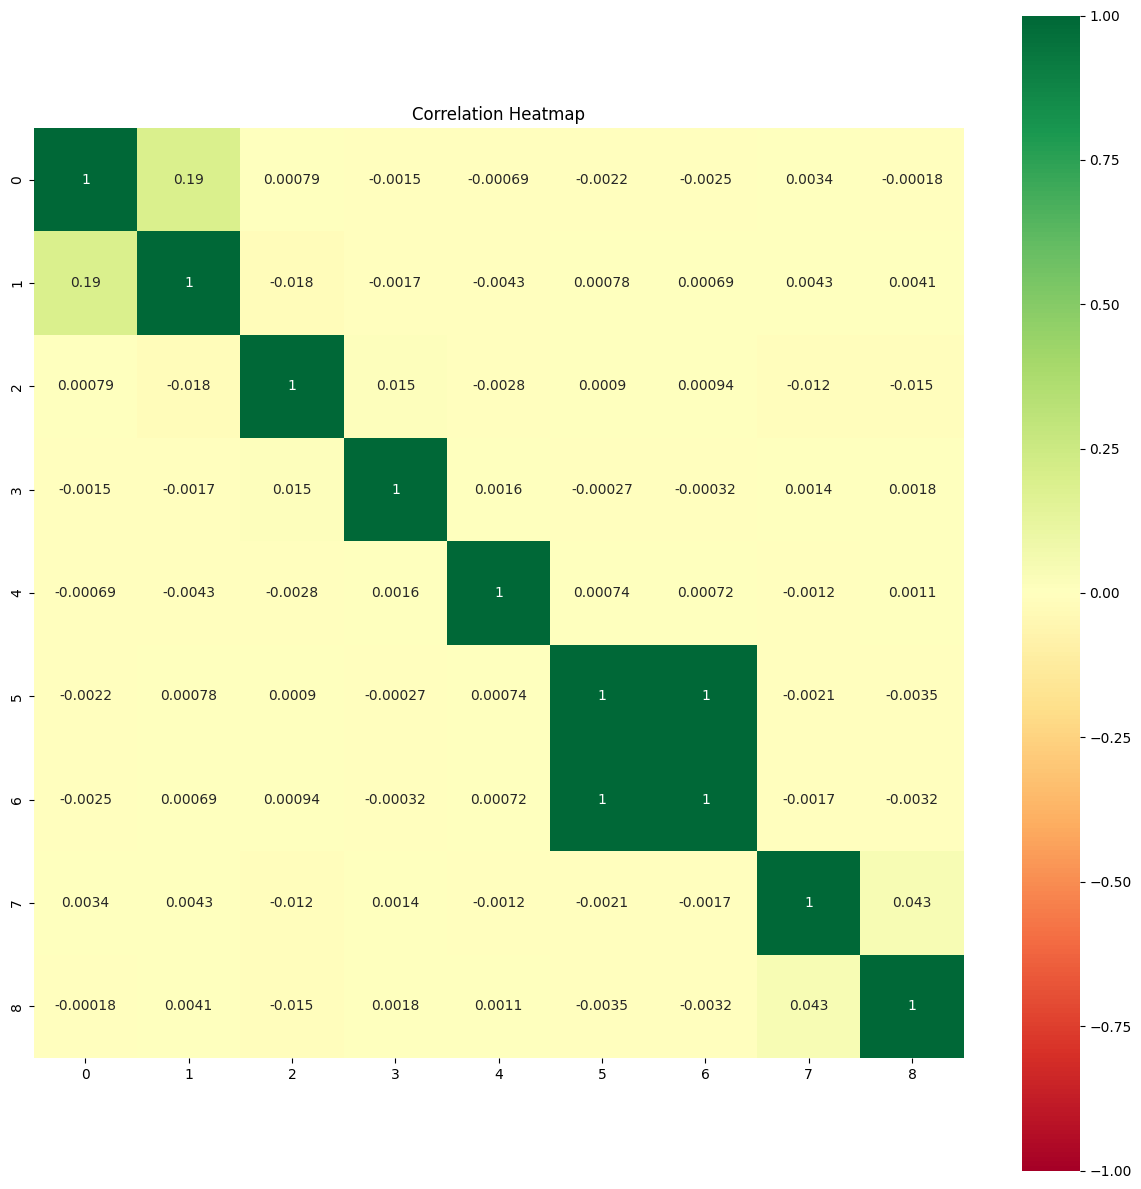

In [59]:


# Convert x_train to DataFrame
x_train_df = pd.DataFrame(x_train)

# Identify non-numeric (categorical) columns
non_numeric_cols = x_train_df.select_dtypes(include=['object']).columns.tolist()
print(f"Non-numeric columns found: {non_numeric_cols}")

# Encode categorical columns to numeric using factorize
for col in non_numeric_cols:
    x_train_df[col] = pd.factorize(x_train_df[col])[0]

# Now calculate correlation matrix (will work without errors)
corr = x_train_df.corr()

# Create correlation heatmap
plt.figure(figsize=(15,15))
sns.heatmap(corr, annot=True, cmap='RdYlGn', vmin=-1, vmax=1, square=True)
plt.title('Correlation Heatmap')
plt.show()


Very Weak Correlations

Low Correlation Range (0-0.19):

* The correlations are extremely weak, indicating these encoded categorical features are largely independent of each other

* Values below 0.2 are generally considered negligible correlations in statistical analysis

* This suggests your feature selection was excellent - you've chosen categorical variables that capture distinct, non-redundant information

**Conclusion**

The exploratory data analysis of the NYC taxi trip dataset reveals that trip duration is primarily influenced by distance, while temporal and passenger-related features have minimal impact. Most trips are short and concentrated in central urban areas, with clear peaks during typical commuting hours. The data is generally clean, and the selected features show low redundancy, making them well-suited for predictive modeling. Overall, these insights provide a strong foundation for building efficient, data-driven solutions to optimize taxi operations and urban mobility.